# 1. import library

In [362]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. data loading

In [363]:
data_test = pd.read_csv("../datasets/test.csv")
data_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [364]:
data_train = pd.read_csv("../datasets/train.csv")
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. data cleaning and transformation

In [365]:
data_train.shape

(891, 12)

In [366]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [367]:
# menampilkan statistik deskriptif dari dataset
data_train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [368]:
def missing_values_check(data):
    # memeriksa jumlah nilai yang hilang di setiap kolom
    missing_values = data_train.isnull().sum()
    return missing_values[missing_values > 0]

In [369]:
missing_values = missing_values_check(data_train)

In [370]:
# pisahkan kolom yang memiliki missing value >= 75% dan < 75%

# isi dengan variable kolom beserta jumlah missing valuenya (default)
# less = missing_values[missing_values < (data_train.shape[0] * 0.75)]
# over = missing_values[missing_values >= (data_train.shape[0] * 0.75)]

# isi dengan variable kolomnya aja
less = missing_values[missing_values < (data_train.shape[0] * 0.75)].index
over = missing_values[missing_values >= (data_train.shape[0] * 0.75)].index

## 3.1 mengisi missing value

### 3.1.1 data numerikal

In [371]:
# Contoh mengisi nilai yang hilang dengan median untuk kolom numerik
numeric_features = data_train[less].select_dtypes(include=['number']).columns
data_train[numeric_features] = data_train[numeric_features].fillna(data_train[numeric_features].median())   
numeric_features

Index(['Age'], dtype='str')

### 3.1.2 data kategorikal

In [372]:
# Contoh mengisi nilai yang hilang dengan mode untuk kolom kategori
categorical_features = data_train[less].select_dtypes(include='str').columns
data_train[categorical_features] = data_train[categorical_features].fillna(data_train[categorical_features].mode())

### 3.1.3 menghapus kolom dengan terlalu banyak nilai yang hilang

In [373]:
data_train = data_train.drop(columns=over)

In [374]:
missing_values = missing_values_check(data_train)

## 3.2 mengatasi outliers

In [375]:
def boxplot_visualization(data, type_of_data):
    numeric_features = data.select_dtypes(include=type_of_data).columns
    for feature in numeric_features:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=data[feature])
        plt.title(f'Box plot of {feature}')
        plt.show()

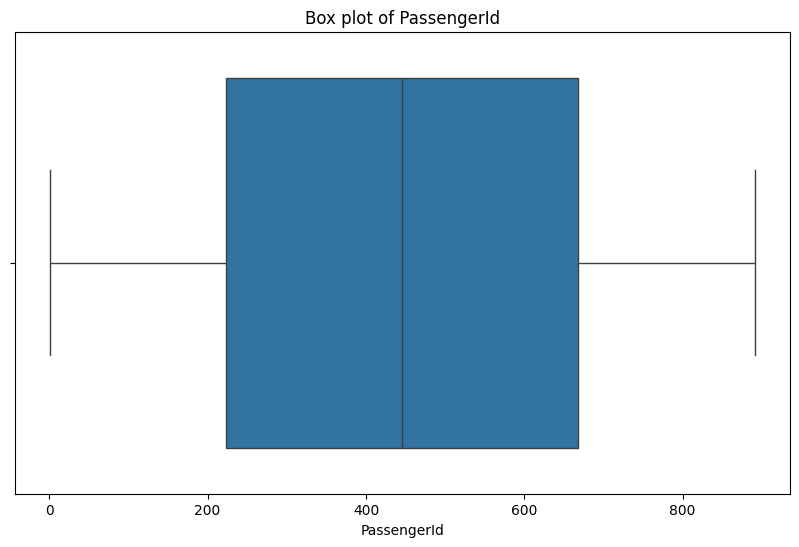

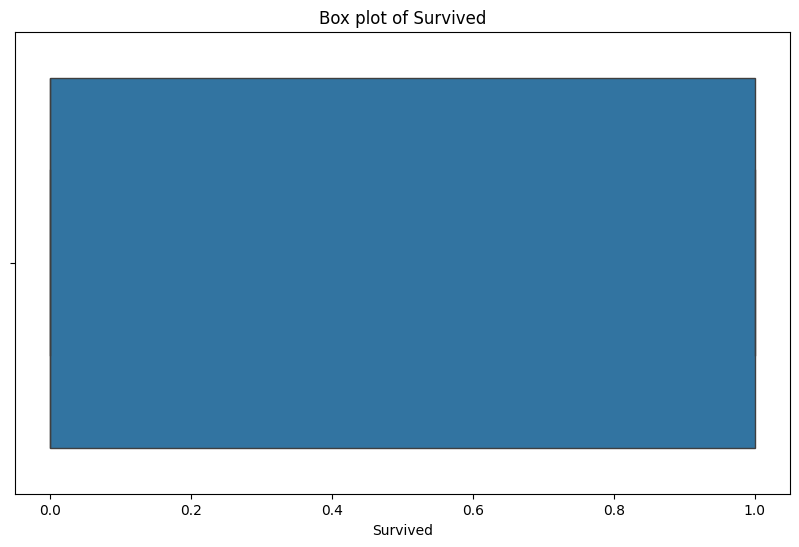

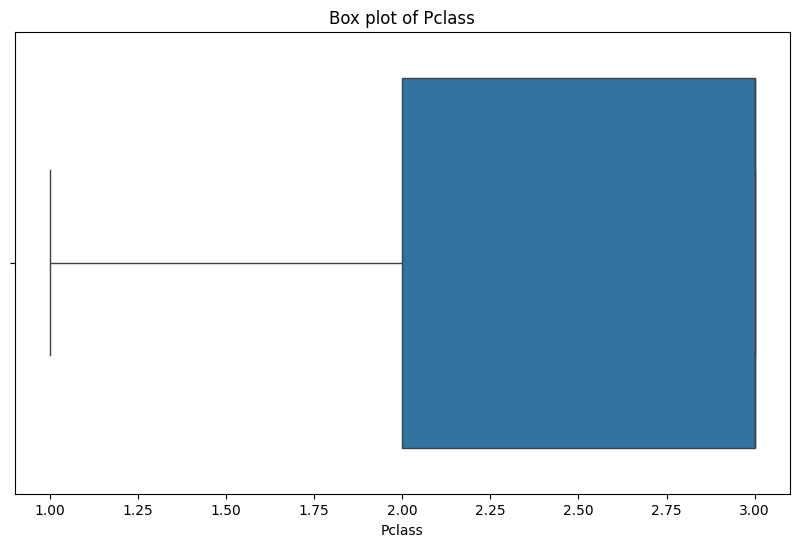

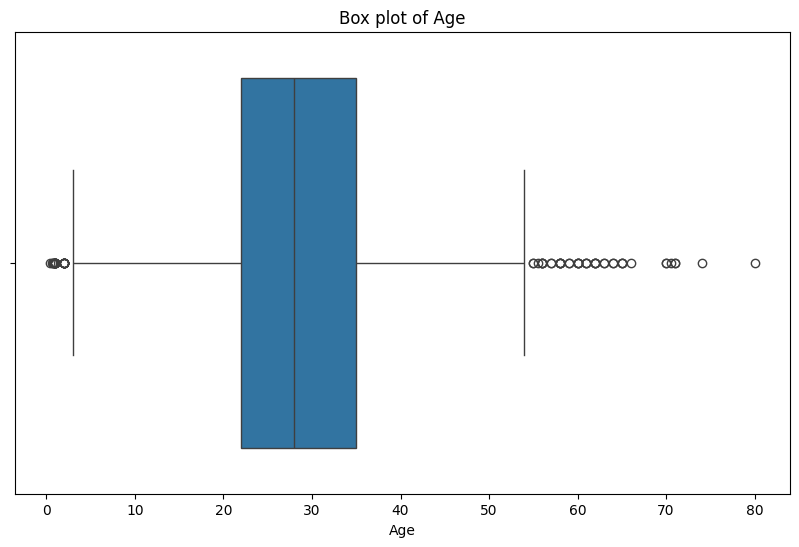

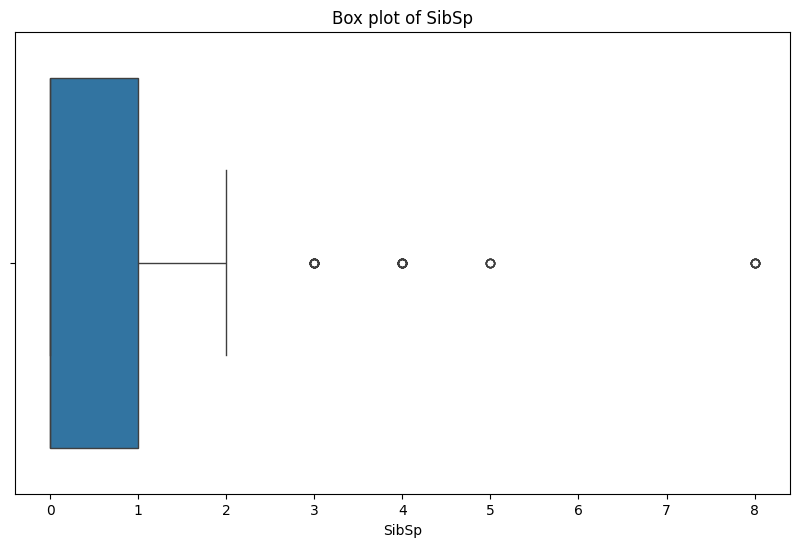

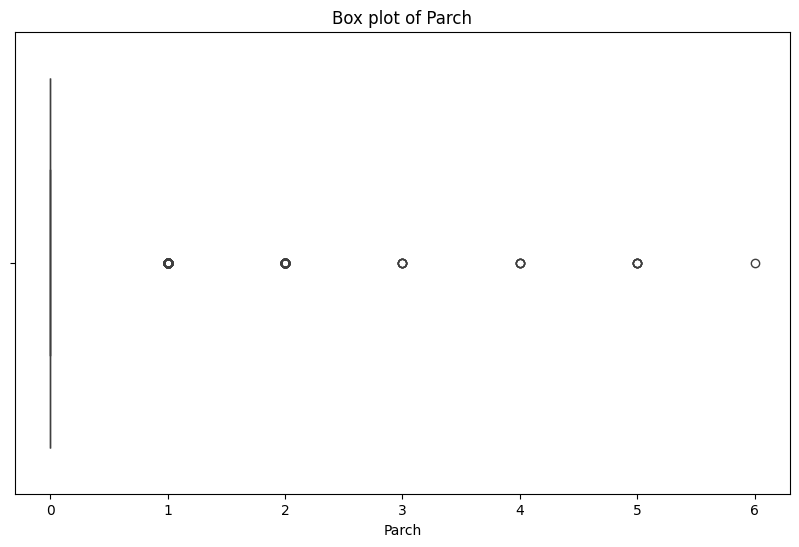

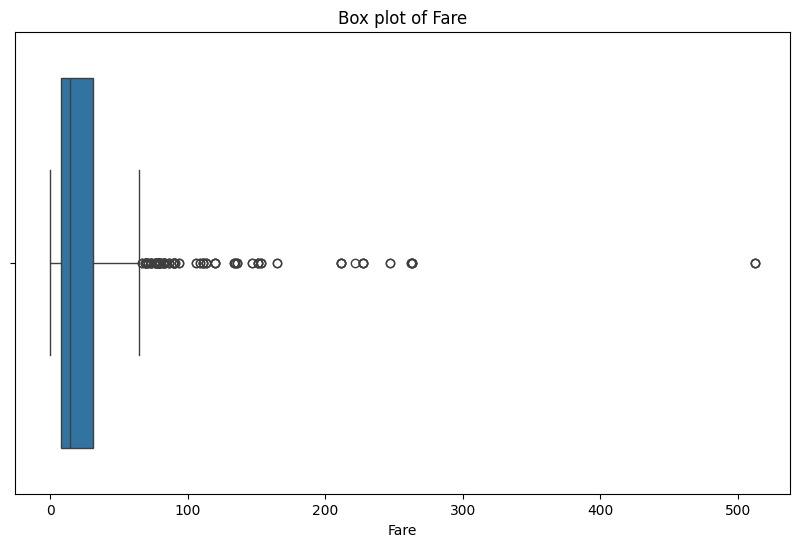

In [376]:
boxplot_visualization(data_train, 'number')

In [377]:
# contoh sederhana untuk mengidentifikasi outliers menggunakan IQR
numeric_features = data_train.select_dtypes('number').columns
Q1 = data_train[numeric_features].quantile(0.25)
Q3 = data_train[numeric_features].quantile(0.75)
IQR = Q3 - Q1

In [378]:
# Filter dataframe untuk hanya menyimpan baris yang tidak mengandung outliers pada kolom numerik
condition = ~((data_train[numeric_features] < (Q1 - 1.5 * IQR)) | (data_train[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)
data_filtered_numeric = data_train.loc[condition, numeric_features]

# Menggabungkan kembali dengan kolom kategorikal
categorical_features = data_train.select_dtypes(include=['str']).columns
data_train = pd.concat([data_filtered_numeric, data_train.loc[condition, categorical_features]], axis=1)

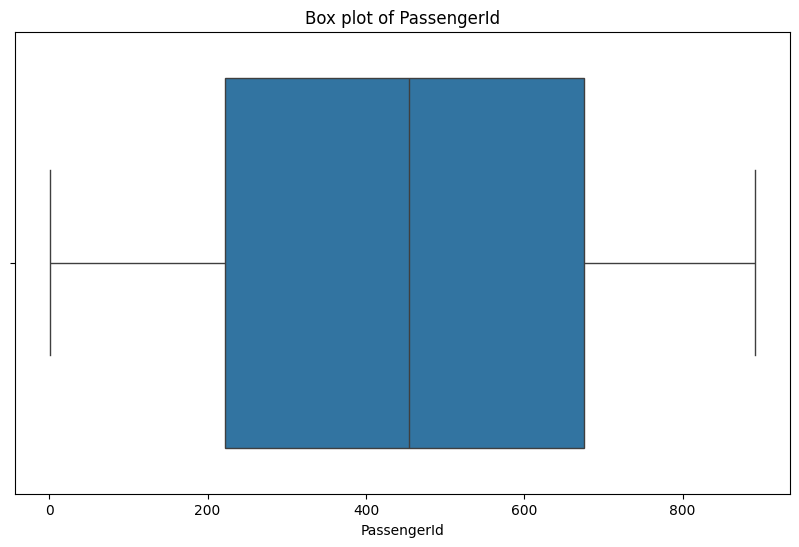

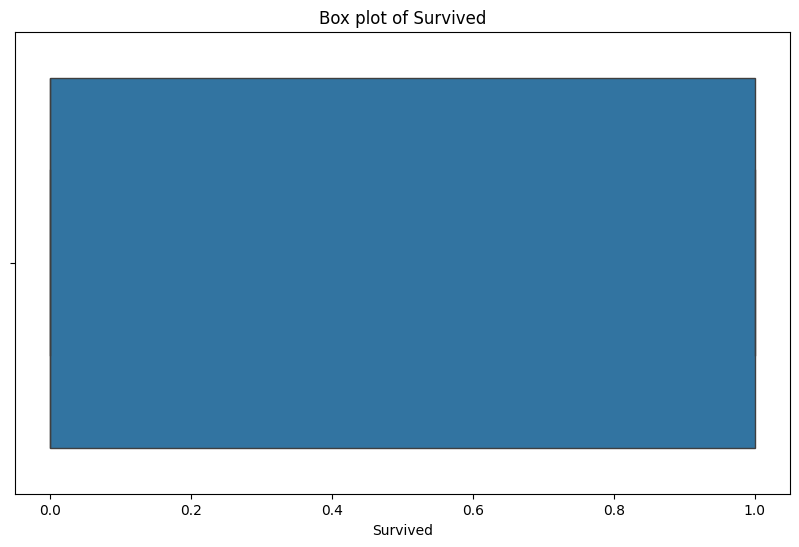

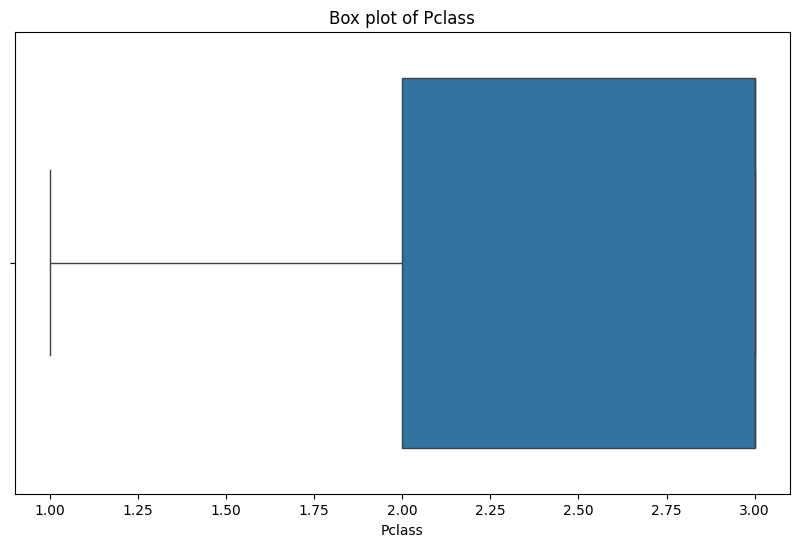

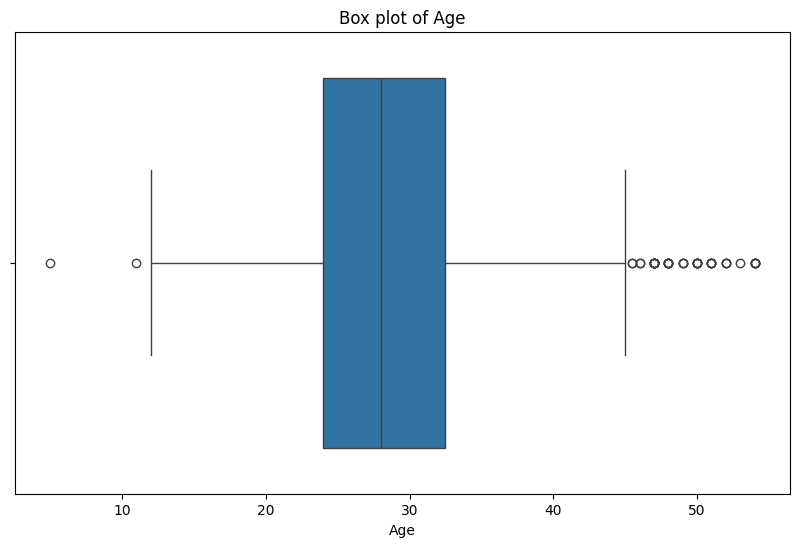

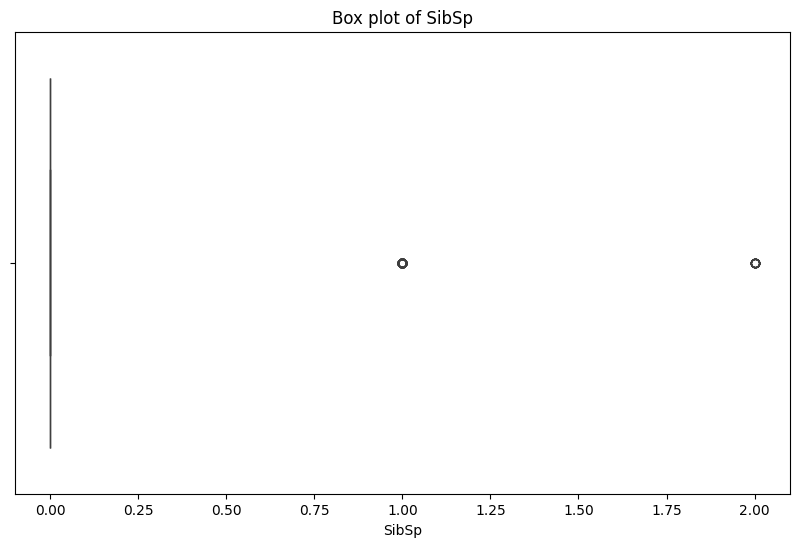

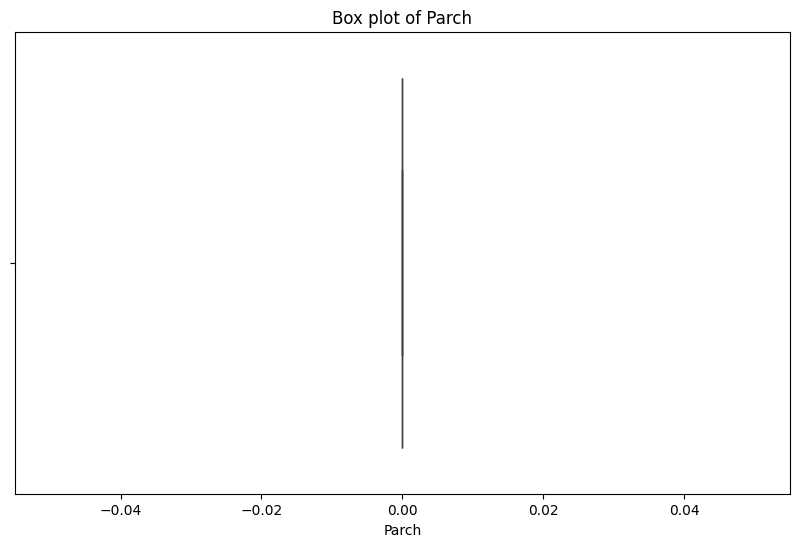

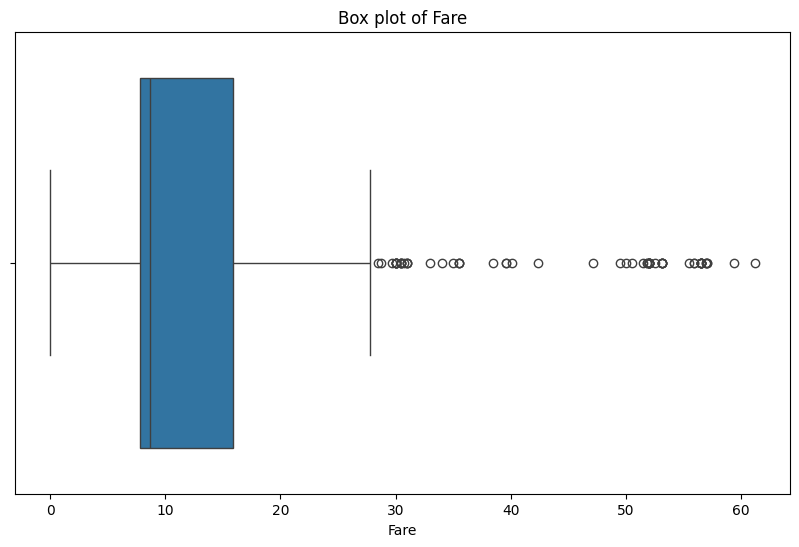

In [379]:
boxplot_visualization(data_train, 'number')

In [381]:
# jika tidak ingin menghapus outliers

# median = df['column_name'].median()
# df['column_name'] = df['column_name'].apply(lambda x: median if x < (Q1 - 1.5  IQR) or x > (Q3 + 1.5  IQR) else x)

# Mengganti outlier dengan nilai batas terdekat
# df['column_name'] = df['column_name'].apply(lambda x: (Q1 - 1.5  IQR) if x < lower_bound else (Q3 + 1.5  IQR) if x > (Q3 + 1.5 * IQR) else x)

## 3.3 feature scaling (normalisasi atau standarisasi)

## 3.4 menangani duplikasi data

## 3.5 mengonversi tipe data

### 3.5.1 one-hot encoding 

### 3.5.2 label encoding 

### 3.5.3 ordinal encoding

# 4. EDA

## 5. splitting data

## 6. pemilihan model

## 7. deployment dan monitoring 